# Regime-Aware, Multi-Asset, Confidence-Gated Stock Movement Predictor

This notebook predicts **next-day up/down movement** for a stock, with three things that make it different from a standard "technical indicators → classifier" project:

1. **Regime awareness** — an unsupervised model (Gaussian Mixture) detects the current market "regime" (e.g. calm/trending vs. volatile/choppy), and a *separate classifier is trained per regime*, since the relationship between indicators and next-day returns is not stable across market conditions.
2. **Multi-asset signal** — features aren't limited to the target stock's own price history. It also uses the sector ETF, VIX (volatility/fear gauge), a bond ETF (risk-on/risk-off proxy), and the S&P 500, since a stock's next-day move is influenced by its broader context, not just its own chart.
3. **Confidence-gated predictions** — the model outputs a probability, and we only "act" on predictions above a confidence threshold, mirroring how a real trader would only take high-conviction trades rather than being forced to guess every single day.

**Honesty up front:** next-day stock movement is close to a random walk. This notebook is built to be *methodologically correct* (no lookahead leakage, walk-forward validation, honest baseline comparison) rather than to claim a magic edge. See the **Limitations** section at the end — read it before you put any number from this notebook on a resume.

### Requirements
```bash
pip install yfinance scikit-learn pandas numpy matplotlib
```
This notebook needs internet access to pull live data via `yfinance`, so run it locally (it won't fetch data in a sandboxed environment).


In [25]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
np.random.seed(42)


## 1. Configuration

Change these to point at whatever stock you care about.

In [26]:
TICKER = "AAPL"          # the stock we're predicting
SECTOR_ETF = "XLK"       # sector proxy (Technology Select Sector SPDR)
VOL_INDEX = "^VIX"       # market fear/volatility gauge
BOND_ETF = "TLT"         # long-term treasuries: risk-on/risk-off proxy
BENCHMARK = "SPY"        # broad market benchmark

START_DATE = "2015-01-01"
END_DATE = None                # None = up to today
N_REGIMES = 3                   # number of latent market regimes to detect
N_WALK_FORWARD_SPLITS = 8       # number of out-of-sample folds
CONFIDENCE_THRESHOLD = 0.60     # only "act" on predictions the model is at least this sure about
TRANSACTION_COST_BPS = 5        # round-trip cost assumption per trade, in basis points


## 2. Data: pull the target stock *and* its market context

This is differentiator #1 (multi-asset signal): we don't just look at the stock's own price history.

In [27]:
def download_prices(tickers, start, end=None):
    raw = yf.download(tickers, start=start, end=end, progress=False)["Close"]
    return raw.ffill().dropna()

tickers = [TICKER, SECTOR_ETF, VOL_INDEX, BOND_ETF, BENCHMARK]
prices = download_prices(tickers, START_DATE, END_DATE)
print(f"Loaded {len(prices)} trading days from {prices.index.min().date()} to {prices.index.max().date()}")
prices.tail()


Loaded 2952 trading days from 2015-01-02 to 2026-09-25


Ticker,AAPL,SPY,TLT,XLK,^VIX
Date,,,,,
2026-09-21,338.980011,773.500000,81.800003,194.850006,14.87
2026-09-22,339.750000,773.380005,81.750000,196.270004,14.21
2026-09-23,337.019989,767.809998,80.459999,195.339996,15.18
2026-09-24,335.920013,767.179993,79.419998,194.710007,15.67
2026-09-25,341.070007,771.349976,79.320000,196.270004,14.87


## 3. Feature engineering

### 3a. Standard technical indicators on the target stock

In [28]:
def add_technical_features(price_series):
    out = pd.DataFrame(index=price_series.index)
    p = price_series

    out["return_1d"] = p.pct_change()
    out["return_5d"] = p.pct_change(5)
    out["return_10d"] = p.pct_change(10)

    sma_10, sma_50 = p.rolling(10).mean(), p.rolling(50).mean()
    out["sma_ratio"] = sma_10 / sma_50

    out["volatility_10d"] = out["return_1d"].rolling(10).std()
    out["volatility_20d"] = out["return_1d"].rolling(20).std()

    delta = p.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    out["rsi_14"] = 100 - (100 / (1 + rs))

    ema12, ema26 = p.ewm(span=12, adjust=False).mean(), p.ewm(span=26, adjust=False).mean()
    out["macd"] = ema12 - ema26
    out["macd_signal"] = out["macd"].ewm(span=9, adjust=False).mean()

    sma20, std20 = p.rolling(20).mean(), p.rolling(20).std()
    out["bb_position"] = (p - sma20) / (2 * std20)

    return out

features = add_technical_features(prices[TICKER])


### 3b. Cross-asset context features (the actual differentiator)

In [29]:
features["vix_level"] = prices[VOL_INDEX]
features["vix_change_5d"] = prices[VOL_INDEX].pct_change(5)
features["sector_return_5d"] = prices[SECTOR_ETF].pct_change(5)
features["bond_return_5d"] = prices[BOND_ETF].pct_change(5)
features["benchmark_return_5d"] = prices[BENCHMARK].pct_change(5)

# Is the stock outperforming its own sector? (relative strength)
features["relative_strength_sector"] = prices[TICKER].pct_change(5) - prices[SECTOR_ETF].pct_change(5)

# Rolling correlation with the market — tends to spike toward 1 in broad sell-offs,
# which is itself a useful regime signal
features["rolling_corr_spy"] = (
    prices[TICKER].pct_change().rolling(20).corr(prices[BENCHMARK].pct_change())
)


### 3c. Target: did the stock go up the next trading day?

In [30]:
features["target"] = (prices[TICKER].pct_change().shift(-1) > 0).astype(int)
features = features.dropna()

print("Class balance (1 = next day up):")
print(features["target"].value_counts(normalize=True).round(3))


Class balance (1 = next day up):
target
1    0.529
0    0.471
Name: proportion, dtype: float64


If the class balance above is close to 50/50 (it usually is, roughly), then a model that just always
guesses the majority class already gets ~50-53% accuracy. **Any model here has to beat that, not beat 50%.**
That's the baseline we compare against later.

## 4. Regime detection + walk-forward validation (the core differentiator)

Two things happen inside this single function, on purpose:

- **Regime detection is unsupervised (Gaussian Mixture Model)** and is refit *inside every fold, using only that fold's training data*. If we fit it once on the whole dataset, the regime labels for early dates would be influenced by data from years later — that's lookahead leakage, and it's the single most common mistake in these projects.
- **Validation is walk-forward, not random train/test split.** Financial data is a time series: shuffling rows before splitting lets the model "see the future," which quietly inflates accuracy. Walk-forward validation only ever trains on the past and tests on the following period, which is what would actually happen in production.
- **One classifier is trained per regime** seen in the training fold (with a fallback global model for any regime that shows up in test but wasn't seen in training).

In [31]:
def walk_forward_regime_ensemble(features, regime_cols, feature_cols, target_col="target",
                                   n_splits=N_WALK_FORWARD_SPLITS, n_regimes=N_REGIMES,
                                   confidence_threshold=CONFIDENCE_THRESHOLD):
    n = len(features)
    fold_size = n // (n_splits + 1)
    rows = []

    for i in range(1, n_splits + 1):
        train_end = fold_size * i
        test_end = min(fold_size * (i + 1), n)
        if test_end <= train_end:
            break

        train, test = features.iloc[:train_end].copy(), features.iloc[train_end:test_end].copy()
        if len(test) == 0:
            continue

        # --- regime model: fit on TRAIN ONLY ---
        scaler_r = StandardScaler()
        X_train_r = scaler_r.fit_transform(train[regime_cols])
        gmm = GaussianMixture(n_components=n_regimes, covariance_type="full", random_state=42)
        gmm.fit(X_train_r)

        train["regime"] = gmm.predict(X_train_r)
        test["regime"] = gmm.predict(scaler_r.transform(test[regime_cols]))

        # --- one classifier per regime ---
        scaler_f = StandardScaler()
        X_train_f = scaler_f.fit_transform(train[feature_cols])
        X_test_f = scaler_f.transform(test[feature_cols])

        models = {}
        for r in np.unique(train["regime"]):
            mask = (train["regime"] == r).values
            if mask.sum() < 20:      # too few samples to trust a regime-specific model
                continue
            clf = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
            clf.fit(X_train_f[mask], train[target_col].values[mask])
            models[r] = clf

        fallback = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
        fallback.fit(X_train_f, train[target_col].values)

        # --- predict with confidence gating ---
        test_regimes = test["regime"].values
        for idx in range(len(test)):
            r = test_regimes[idx]
            model = models.get(r, fallback)
            proba = model.predict_proba(X_test_f[idx:idx + 1])[0]
            pred = int(np.argmax(proba))
            confidence = float(proba.max())

            rows.append({
                "date": test.index[idx],
                "regime": r,
                "prediction": pred,
                "confidence": confidence,
                "actual": int(test[target_col].values[idx]),
                "acted": confidence >= confidence_threshold,
            })

    return pd.DataFrame(rows)


feature_cols = [
    "return_1d", "return_5d", "return_10d", "sma_ratio",
    "volatility_10d", "volatility_20d", "rsi_14", "macd", "macd_signal", "bb_position",
    "vix_level", "vix_change_5d", "sector_return_5d", "bond_return_5d", "benchmark_return_5d",
    "relative_strength_sector", "rolling_corr_spy",
]
regime_cols = ["volatility_20d", "sma_ratio", "vix_level", "benchmark_return_5d"]

results = walk_forward_regime_ensemble(features, regime_cols, feature_cols)
print(f"{len(results)} out-of-sample predictions across {N_WALK_FORWARD_SPLITS} walk-forward folds")
results.head()


2576 out-of-sample predictions across 8 walk-forward folds


,date,regime,prediction,confidence,actual,acted
0,2016-06-23,1,0,0.977608,0,True
1,2016-06-24,0,0,0.832671,0,True
2,2016-06-27,0,0,0.976423,1,True
3,2016-06-28,1,1,0.833560,1,True
4,2016-06-29,1,0,0.756613,1,True


## 5. Evaluation — against an honest baseline, and with confidence gating

In [32]:
overall_acc = accuracy_score(results["actual"], results["prediction"])
baseline_acc = max(features["target"].mean(), 1 - features["target"].mean())

acted = results[results["acted"]]
acted_acc = accuracy_score(acted["actual"], acted["prediction"]) if len(acted) else float("nan")
coverage = len(acted) / len(results)

print(f"Naive majority-class baseline accuracy:        {baseline_acc:.3f}")
print(f"Model accuracy on ALL out-of-sample days:       {overall_acc:.3f}")
print(f"Model accuracy on HIGH-CONFIDENCE days only:    {acted_acc:.3f}   (coverage: {coverage:.1%} of days)")
print()
print("If 'high-confidence' accuracy isn't meaningfully above the baseline, the confidence score")
print("isn't actually tracking real predictive signal -- that's a useful, honest thing to know.")


Naive majority-class baseline accuracy:        0.529
Model accuracy on ALL out-of-sample days:       0.493
Model accuracy on HIGH-CONFIDENCE days only:    0.501   (coverage: 69.6% of days)

If 'high-confidence' accuracy isn't meaningfully above the baseline, the confidence score
isn't actually tracking real predictive signal -- that's a useful, honest thing to know.


### Per-regime breakdown

Does the model do better in some market regimes than others? (It's common for regime-specific accuracy to vary more than the overall number suggests.)

In [33]:
regime_summary = results.groupby("regime").apply(
    lambda d: pd.Series({
        "n_days": len(d),
        "accuracy": accuracy_score(d["actual"], d["prediction"]),
        "avg_confidence": d["confidence"].mean(),
    })
)
regime_summary


,n_days,accuracy,avg_confidence
regime,,,
0,879.0,0.483504,0.675276
1,1119.0,0.492404,0.701955
2,578.0,0.506920,0.758345


## 6. Backtest: confidence-gated strategy vs. buy-and-hold

**This is a simplified backtest, not a production trading simulation.** It assumes you can trade at the close with no slippage beyond the flat cost assumption below, and it ignores taxes, position sizing, and liquidity. Treat it as a sanity check, not a P&L projection.

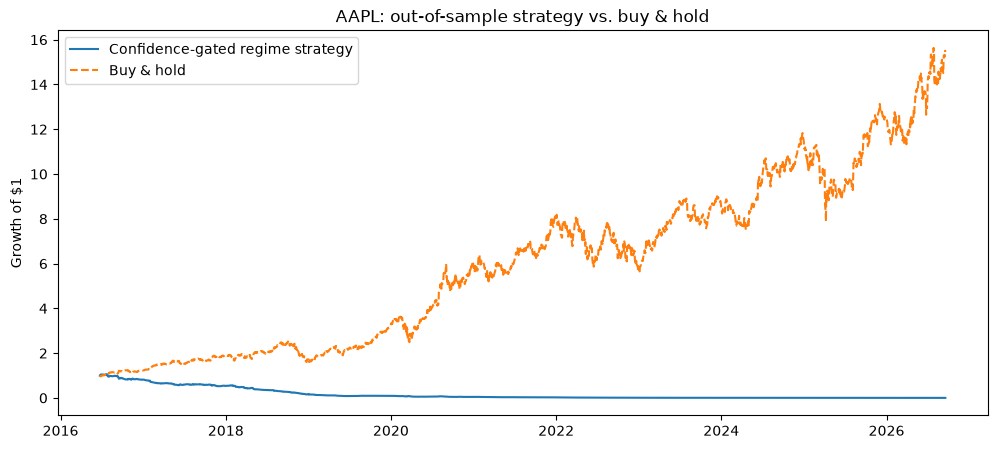

Strategy   -- Sharpe: -2.22   Max drawdown: -99.9%
Buy & hold -- Sharpe: 1.07   Max drawdown: -38.5%


In [34]:
def backtest_strategy(results, prices, ticker, cost_bps=TRANSACTION_COST_BPS):
    df = results.set_index("date").sort_index()
    daily_ret = prices[ticker].pct_change().reindex(df.index)

    strat_ret = np.where(
        df["acted"],
        np.where(df["prediction"] == 1, daily_ret, -daily_ret) - cost_bps / 10_000,
        0.0,
    )
    df["strategy_return"] = strat_ret
    df["buy_hold_return"] = daily_ret
    df["strategy_equity"] = (1 + df["strategy_return"].fillna(0)).cumprod()
    df["buy_hold_equity"] = (1 + df["buy_hold_return"].fillna(0)).cumprod()
    return df


def sharpe(returns, periods_per_year=252):
    r = returns.dropna()
    return np.sqrt(periods_per_year) * r.mean() / r.std() if r.std() > 0 else np.nan


def max_drawdown(equity):
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    return drawdown.min()


bt = backtest_strategy(results, prices, TICKER)

plt.plot(bt.index, bt["strategy_equity"], label="Confidence-gated regime strategy")
plt.plot(bt.index, bt["buy_hold_equity"], label="Buy & hold", linestyle="--")
plt.title(f"{TICKER}: out-of-sample strategy vs. buy & hold")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

print(f"Strategy   -- Sharpe: {sharpe(bt['strategy_return']):.2f}   Max drawdown: {max_drawdown(bt['strategy_equity']):.1%}")
print(f"Buy & hold -- Sharpe: {sharpe(bt['buy_hold_return']):.2f}   Max drawdown: {max_drawdown(bt['buy_hold_equity']):.1%}")


## 7. What is the model actually using? (feature importance + regime visualization)

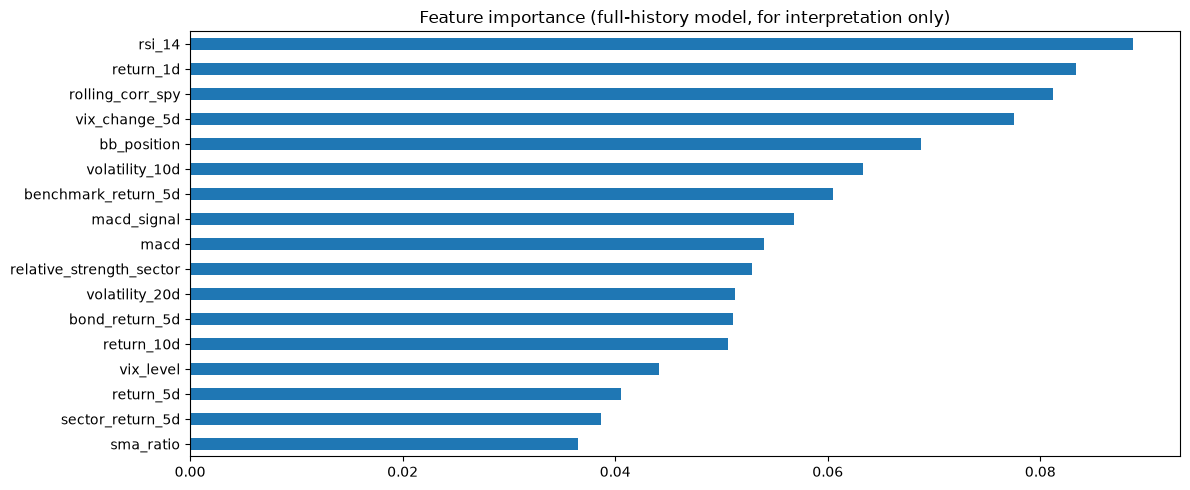

In [35]:
# Feature importance from a model trained on the full feature set (for interpretability only --
# not used anywhere in the walk-forward evaluation above)
scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(features[feature_cols])
importance_model = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
importance_model.fit(X_full, features["target"].values)

importances = pd.Series(importance_model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", title="Feature importance (full-history model, for interpretation only)")
plt.tight_layout()
plt.show()


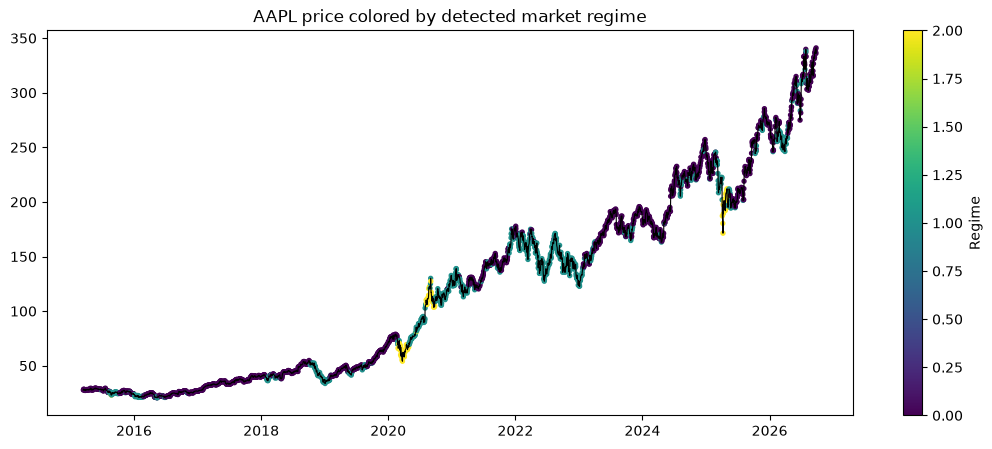

In [36]:
# Visualize detected regimes over the price history (fit on full history here, for display purposes only)
scaler_r_full = StandardScaler()
X_r_full = scaler_r_full.fit_transform(features[regime_cols])
gmm_full = GaussianMixture(n_components=N_REGIMES, covariance_type="full", random_state=42)
regime_labels = gmm_full.fit_predict(X_r_full)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(features.index, prices[TICKER].reindex(features.index), color="black", linewidth=0.8)
scatter = ax.scatter(features.index, prices[TICKER].reindex(features.index), c=regime_labels, cmap="viridis", s=8)
ax.set_title(f"{TICKER} price colored by detected market regime")
plt.colorbar(scatter, label="Regime")
plt.show()


## 8. Limitations — read this before putting a number from this notebook anywhere

Be upfront about these if you talk about this project in an interview; it will land far better than presenting the accuracy number alone:

- **Next-day price movement is close to a random walk.** Public markets are close to informationally efficient, so a small accuracy edge over the 50/53% baseline (a few points) is consistent with noise and is *not* strong evidence of a real, tradeable signal on its own.
- **Walk-forward validation avoids lookahead leakage, but not multiple-comparisons risk.** Trying several feature sets, regime counts, or thresholds and reporting the best one overstates how well it will generalize. The honest move is to pick your configuration once, in advance, and not tune it against this test period.
- **Regimes are unsupervised and not guaranteed to match human labels like "bull" or "bear."** They're just clusters in volatility/trend/VIX space — inspect them before assuming they mean what you think they mean.
- **The backtest is simplified.** Real trading involves slippage beyond a flat cost assumption, position sizing, liquidity constraints, taxes, and margin/borrowing costs for short positions — all ignored here.
- **This predicts direction, not magnitude.** Being right on direction with a tiny move and wrong on direction with a large move nets out badly; a magnitude-aware evaluation (e.g., weighting by realized return) would be more honest than accuracy alone.

### Suggested next steps if you want to take this further
- Run this across a basket of 10-20 tickers and report the *distribution* of out-of-sample accuracy, not one ticker's number.
- Add a statistical significance test (e.g., is out-of-sample accuracy significantly above baseline given the sample size?).
- Paper-trade the confidence-gated signal for a few months before treating any of this as more than a portfolio project.
